In [2]:
# PHASE 1: RISK ENGINE

In [3]:
# Calculating the log returns of the stocks within the portfolio

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
import statsmodels.api as sm
import yfinance as yf

In [5]:
n = int(input("Enter the number of stocks in your portfolio: "))
tickers = []
weight = []

# Logging the stocks within the portfolio of the user; and the weightage each of them carries in the portfolio
# (I can ig optimize this by storing the stock and its weight in a pair)

for i in range(n):
    stock = input("Enter the stock in your portfolio: ")
    tickers.append(stock)
    wt = int(input("Enter its weightage within your portfolio: "))
    weight.append(wt)

print(tickers, weight)

['AAPL', 'NKE', 'LULU'] [80, 10, 10]


In [6]:
data = pd.DataFrame()

# Used a for loop to fetch all the sources,
# and made it (the comment and the code)
# multi-line to avoid getting flagged by Ruff

for ticker in tickers:
    data[ticker] = yf.download(
        ticker,
        start="2015-01-01",
        auto_adjust=False,
    )["Adj Close"]

data.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,AAPL,NKE,LULU
Date,,,
2015-01-02,24.171755,40.316387,55.340000
2015-01-05,23.490799,39.667282,55.959999
2015-01-06,23.493010,39.433960,55.570000
2015-01-07,23.822432,40.248505,57.650002
2015-01-08,24.737751,41.177601,59.070000


In [7]:
log_returns_of_portfolio = pd.DataFrame()
column_list = data.columns.tolist()

# Calculated the Log Return
# Not simple return coz,
# simple return = Single portfolio comparison
# log return = multiple portfolio comparsion

for ticker in column_list:
    log_returns_of_portfolio[ticker] = np.log(data[ticker] / data[ticker].shift(1))

log_returns_of_portfolio.head()

,AAPL,NKE,LULU
Date,,,
2015-01-02,NaN,NaN,NaN
2015-01-05,-0.028576,-0.016231,0.011141
2015-01-06,0.000094,-0.005899,-0.006994
2015-01-07,0.013925,0.020445,0.036747
2015-01-08,0.037703,0.022822,0.024333


In [8]:
# Annualization of the data

In [9]:
annualized_return = pd.DataFrame(index=["Annualized Return"])

for ticker in column_list:
    mean_daily_log_return = log_returns_of_portfolio[ticker].mean()

    # recently learnt should prefer 252 over 250
    # for number of trading days within a year
    annualized_return[ticker] = np.exp(mean_daily_log_return * 252) - 1

print(annualized_return)

                       AAPL       NKE      LULU
Annualized Return  0.250991 -0.014753  0.046669


In [10]:
# calculating standard deviation, variance, covariance and correlation

In [11]:
# Just now learnt the concept of "VECTORIZATION".
# Thanks to vectorization, we do not require to loop through
# all the stocks in the portfolio and calculate the variance individually,
# but rather can do the task within one single statement

# THEREFORE,

annualized_variance_of_stocks = log_returns_of_portfolio.var() * 252
annualized_standard_deviation_of_stocks = log_returns_of_portfolio.std() * np.sqrt(252)
annualized_covariance_of_stocks = log_returns_of_portfolio.cov() * 252
# Correlation is a unitless ratio and thus doesn't require to be multiplied with 250
annualized_correlation_of_stocks = log_returns_of_portfolio.corr()

print(f"Annualized std deviation: {annualized_standard_deviation_of_stocks}\n")
print(f"Annualized variance: {annualized_variance_of_stocks}\n")
print(f"Annualized covariance: {annualized_covariance_of_stocks}\n")
print(f"Annualized correlation: {annualized_correlation_of_stocks}\n")

Annualized std deviation: AAPL    0.286868
NKE     0.314604
LULU    0.410832
dtype: float64

Annualized variance: AAPL    0.082293
NKE     0.098976
LULU    0.168783
dtype: float64

Annualized covariance:           AAPL       NKE      LULU
AAPL  0.082293  0.038546  0.042322
NKE   0.038546  0.098976  0.061498
LULU  0.042322  0.061498  0.168783

Annualized correlation:           AAPL       NKE      LULU
AAPL  1.000000  0.427103  0.359102
NKE   0.427103  1.000000  0.475807
LULU  0.359102  0.475807  1.000000



In [12]:
# variance of the portfolio

In [13]:
# variance of a portfoliio, i.e.,
# ((omega1 * sigma1) + (omega2 * sigma2))^2
# =   (omega1^2 * sigma1^2) +
#     (omega2^2 * sigma2^2) +
#     (2 * omega1 * omega2 * sigma1 * sigma2)

# WHERE, omega1 = weightage of stock1 in the portfolio
#        omega2 = weightage of stock2 in the portfolio
#        sigma1 = standard deviation of stock1
#        sigma2 = standard deviation of stock

# BUT, in this scenario, we have the annual standard deviation collectively
# and thus, we can apply the formula:

# Portfolio variance = omega^T * Sigma(Σ) * omega

# WHERE,  omega = vector of weights
#         omega^T = Transposed vector of those weights
#         Sigma (Σ) = Covariance matrix (here, annualized_covariance_of_stocks)

In [14]:
weights_array = np.array(weight) / 100  # divided by 100 to get the decimal values
variance_of_portfolio = np.dot(weights_array.T, np.dot(annualized_covariance_of_stocks, weights_array))
print(f"Variance of the portfolio is: {variance_of_portfolio}")

Variance of the portfolio is: 0.06951422684583655


In [15]:
# Calculating the portfolio return

# Portfolio return = omega1 * R1 + omega2 * R2 + .....

# OR

# Portfolio return = omega^T dot-product R

# WHERE,  omega1 = weight of stock1,
#         omega2 = weight of stock2, ...
#         omega = weights vector
#         omega^T = Transposed vector of weights vector
#         R1 = return of stock1
#         R2 = return of stock2, ...
#         R = returns vector

In [16]:
individual_returns = annualized_return.iloc[0]
portfolio_return = np.dot(weights_array.T, individual_returns)
print(f"Annual portfolio return: {portfolio_return}")

Annual portfolio return: 0.20398433198571203


In [17]:
# Sharpe Ratio

# Sharpe ratio = (risk-free rate - excess return of stock "i") / standard deviation of stock "i"

# Other way to calculate Sharpe Ratio is:
#     Sharpe Ratio = (portfolio return - risk-free rate) / portfolio  volatility
#
# (portfolio volatility = sqrt of the variance of the portfolio)

In [18]:
us_treasury_yield = yf.download("^TNX", period="5d", auto_adjust=False)["Adj Close"]
# Cause we take risk free rate as the current yield on a 10 year US Treasury bond

risk_free_rate = float(us_treasury_yield.iloc[-1].iloc[0]) / 100
print("Current risk-free rate: ", risk_free_rate)

[*********************100%***********************]  1 of 1 completed

Current risk-free rate:  0.05276999950408936


In [19]:
sharpe_ratio = (portfolio_return - risk_free_rate) / np.sqrt(variance_of_portfolio)
print("Sharpe ratio of the portfolio is: ", sharpe_ratio)

Sharpe ratio of the portfolio is:  0.5735299584151339


In [20]:
# PHASE 2: PORTFOLIO OPTIMIZATION THEORY

In [21]:
# Markowitz Portfolio Optimization Theory
# Also calculating the variance and sharpe on each simulation

In [22]:
portfolio_returns = []
portfolio_volatilites = []

max_sharpe = -np.inf
max_sharpe_weights = None

min_variance = np.inf
min_variance_weights = None

for x in range(10000):
    # Calculating the random weights to uuse in the markowitz portfolio optimization theory
    new_weights = np.random.random(n)
    new_weights /= np.sum(new_weights)

    # Calculating and updating the minimum variance during the 10000 simulations
    variance_of_simulation = np.dot(new_weights.T, np.dot(annualized_covariance_of_stocks, new_weights))
    if variance_of_simulation < min_variance:
        min_variance = min(min_variance, variance_of_simulation)
        min_variance_weights = new_weights.copy()

    # Calculating and adding the portfolio returns and volatilities across the 10000 simulations
    portfolio_returns.append(np.sum(new_weights * log_returns_of_portfolio.mean()) * 252)
    portfolio_volatilites.append(np.sqrt(variance_of_simulation))

    # Calculating the sharpe for the simulations and updating the max sharpe
    sharpe_of_simulation = (portfolio_returns[x] - risk_free_rate) / portfolio_volatilites[x]
    if max_sharpe < sharpe_of_simulation:
        max_sharpe = max(max_sharpe, sharpe_of_simulation)
        max_sharpe_weights = new_weights.copy()

portfolio_returns = np.array(portfolio_returns)
portfolio_volatilites = np.array(portfolio_volatilites)

print("Expected portfolio returns: ", portfolio_returns)
print("Expected portfolio volatilies: ", portfolio_volatilites)
print("Max Sharpe: ", max_sharpe)
print("Minimum variance: ", min_variance)

Expected portfolio returns:  [0.13546352 0.07342546 0.06939712 ... 0.07173642 0.06201728 0.13831361]
Expected portfolio volatilies:  [0.25990351 0.26924168 0.26040854 ... 0.27484762 0.26367314 0.25121278]
Max Sharpe:  0.5795968500859056
Minimum variance:  0.06249441703175883


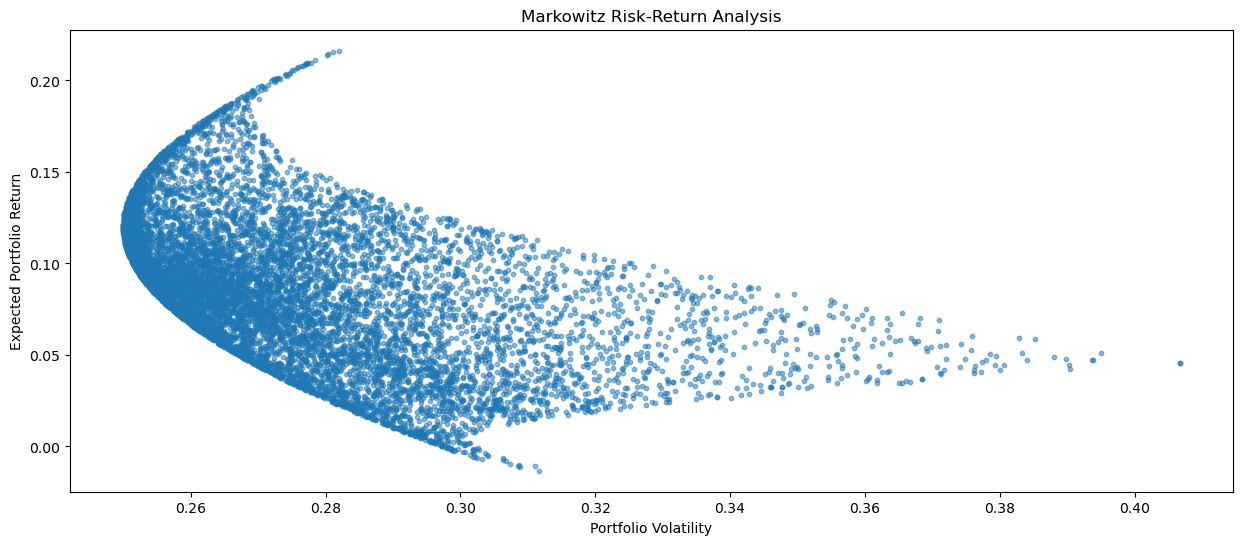

In [23]:
# Calculating the efficient frontier
plt.figure(figsize=(15, 6))
plt.scatter(portfolio_volatilites, portfolio_returns, s=10, alpha=0.5)

plt.xlabel("Portfolio Volatility")
plt.ylabel("Expected Portfolio Return")
plt.title("Markowitz Risk-Return Analysis")

plt.show()

In [24]:
sorted_indices = np.argsort(portfolio_volatilites)

sorted_volatilities = portfolio_volatilites[sorted_indices]

sorted_returns = portfolio_returns[sorted_indices]

max_return_so_far = np.maximum.accumulate(sorted_returns)

efficient_mask = sorted_returns >= max_return_so_far

efficient_volatilities = sorted_volatilities[efficient_mask]

efficient_returns = sorted_returns[efficient_mask]

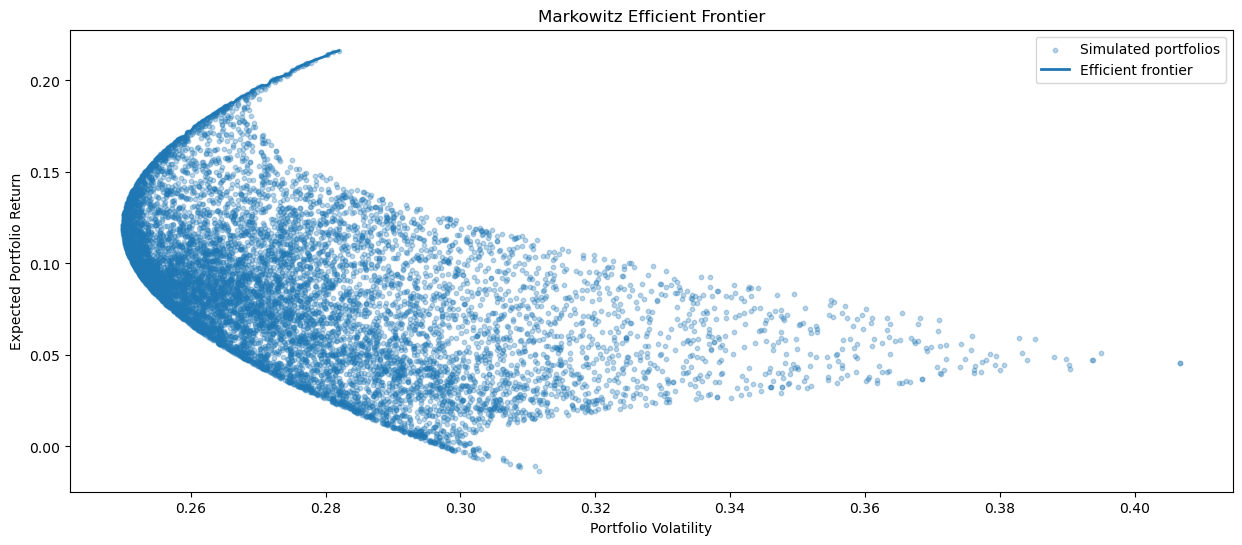

In [25]:
plt.figure(figsize=(15, 6))

# All simulated portfolios
plt.scatter(portfolio_volatilites, portfolio_returns, s=10, alpha=0.3, label="Simulated portfolios")

# Efficient frontier
plt.plot(efficient_volatilities, efficient_returns, linewidth=2, label="Efficient frontier")

plt.xlabel("Portfolio Volatility")
plt.ylabel("Expected Portfolio Return")
plt.title("Markowitz Efficient Frontier")
plt.legend()

plt.show()

In [26]:
# CAPM

# beta = covariance with market / (variance of the market) ^ 2


In [27]:
# Using the S&P 500 as the market benchmark

market_data = yf.download(
    "^GSPC",
    start="2015-01-01",
    auto_adjust=False,
)["Adj Close"]

market_data = market_data.squeeze()  # converts the dataframe with one column to a panda series

market_returns = np.log(market_data / market_data.shift(1)).dropna()

market_returns.name = "MARKET"

market_returns.head()

[*********************100%***********************]  1 of 1 completed


Date
2015-01-05   -0.018447
2015-01-06   -0.008933
2015-01-07    0.011563
2015-01-08    0.017730
2015-01-09   -0.008439
Name: MARKET, dtype: float64

In [28]:
# Calculate covariance of each stock with the market

returns_with_market = pd.concat(
    [
        log_returns_of_portfolio,
        market_returns,
    ],
    axis=1,
).dropna()

covariance_matrix_with_market = returns_with_market.cov()

covariance_with_market = covariance_matrix_with_market["MARKET"].drop("MARKET")

market_variance = market_returns.var()

beta = covariance_with_market / market_variance

print("Covariance with market:")
print(covariance_with_market)

print("\nMarket variance:")
print(market_variance)

print("\nBeta:")
print(beta)

Covariance with market:
AAPL    0.000147
NKE     0.000125
LULU    0.000140
Name: MARKET, dtype: float64

Market variance:
0.00012410297406226215

Beta:
AAPL    1.181571
NKE     1.006941
LULU    1.130787
Name: MARKET, dtype: float64


In [29]:
# Calculate annualized historical market return
# and risk premium and the CAPM expected return

annualized_market_return = market_returns.mean() * 252

print(f"Annualized market return: {annualized_market_return:.2%}")

market_risk_premium = annualized_market_return - risk_free_rate

capm_expected_return = risk_free_rate + beta * market_risk_premium

print("CAPM expected return:")
print(capm_expected_return)

Annualized market return: 11.28%
CAPM expected return:
AAPL    0.123707
NKE     0.113223
LULU    0.120658
Name: MARKET, dtype: float64


In [30]:
# Convert annual risk-free rate to an approximate daily rate

daily_risk_free_rate = (1 + risk_free_rate) ** (1 / 252) - 1

# Calculate daily excess returns
stock_excess_returns = returns_with_market.drop(columns="MARKET") - daily_risk_free_rate
market_excess_returns = returns_with_market["MARKET"] - daily_risk_free_rate

In [31]:
# Run CAPM regression for each stock
regression_results = {}

for stock in stock_excess_returns.columns:
    X = sm.add_constant(market_excess_returns)
    y = stock_excess_returns[stock]

    model = sm.OLS(y, X).fit()

    regression_results[stock] = model

In [32]:
# Extract regression statistics
alpha = pd.Series({stock: regression_results[stock].params["const"] for stock in regression_results})

regression_beta = pd.Series({stock: regression_results[stock].params["MARKET"] for stock in regression_results})

r_squared = pd.Series({stock: regression_results[stock].rsquared for stock in regression_results})

print("Regression alpha:")
print(alpha)

print("\nRegression beta:")
print(regression_beta)

print("\nR²:")
print(r_squared)

Regression alpha:
AAPL    0.000397
NKE    -0.000508
LULU   -0.000298
dtype: float64

Regression beta:
AAPL    1.181571
NKE     1.006941
LULU    1.130787
dtype: float64

R²:
AAPL    0.530563
NKE     0.320377
LULU    0.236928
dtype: float64


In [33]:
# Compare beta calculated from covariance with regression beta
beta_comparison = pd.DataFrame(
    {
        "Covariance Beta": beta,
        "Regression Beta": regression_beta,
    }
)

beta_comparison["Difference"] = beta_comparison["Covariance Beta"] - beta_comparison["Regression Beta"]

beta_comparison

,Covariance Beta,Regression Beta,Difference
AAPL,1.181571,1.181571,-1.776357e-15
NKE,1.006941,1.006941,0.000000e+00
LULU,1.130787,1.130787,-2.220446e-15


In [34]:
# Calculate annualized historical returns for each stock
annualized_stock_returns = log_returns_of_portfolio.mean() * 252

return_comparison = pd.DataFrame(
    {
        "Historical Return": annualized_stock_returns,
        "CAPM Expected Return": capm_expected_return,
    }
)

return_comparison["Difference"] = return_comparison["Historical Return"] - return_comparison["CAPM Expected Return"]

return_comparison

,Historical Return,CAPM Expected Return,Difference
AAPL,0.223936,0.123707,0.100229
NKE,-0.014863,0.113223,-0.128086
LULU,0.045613,0.120658,-0.075045


In [35]:
# Calculate regression residuals
residuals = pd.DataFrame(index=returns_with_market.index)

for stock in stock_excess_returns.columns:
    residuals[stock] = regression_results[stock].resid

residuals.head()

# Summarize residual behavior
residual_summary = pd.DataFrame(
    {
        "Mean Residual": residuals.mean(),
        "Residual Std Dev": residuals.std(),
        "Min Residual": residuals.min(),
        "Max Residual": residuals.max(),
    }
)

residual_summary

,Mean Residual,Residual Std Dev,Min Residual,Max Residual
AAPL,-5.261720e-19,0.012381,-0.084989,0.090175
NKE,-1.503349e-19,0.016338,-0.218275,0.141534
LULU,-1.578516e-18,0.022607,-0.270070,0.144977


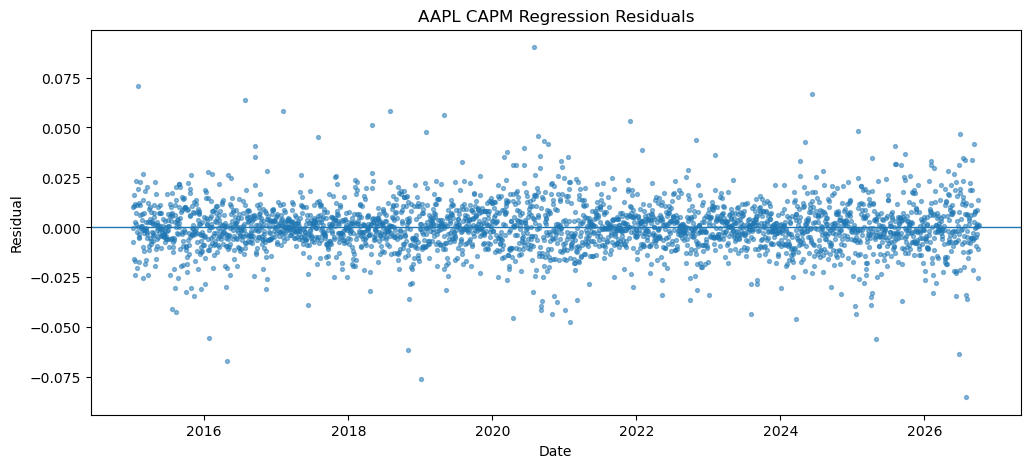

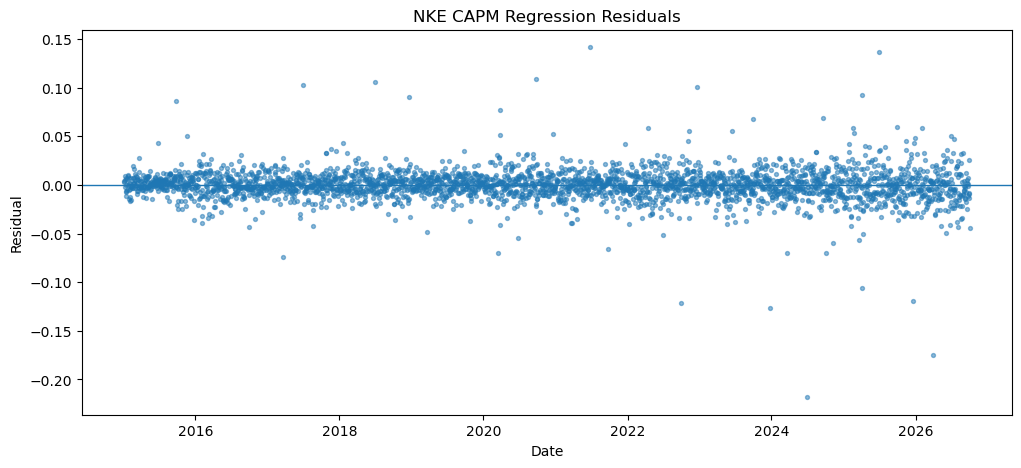

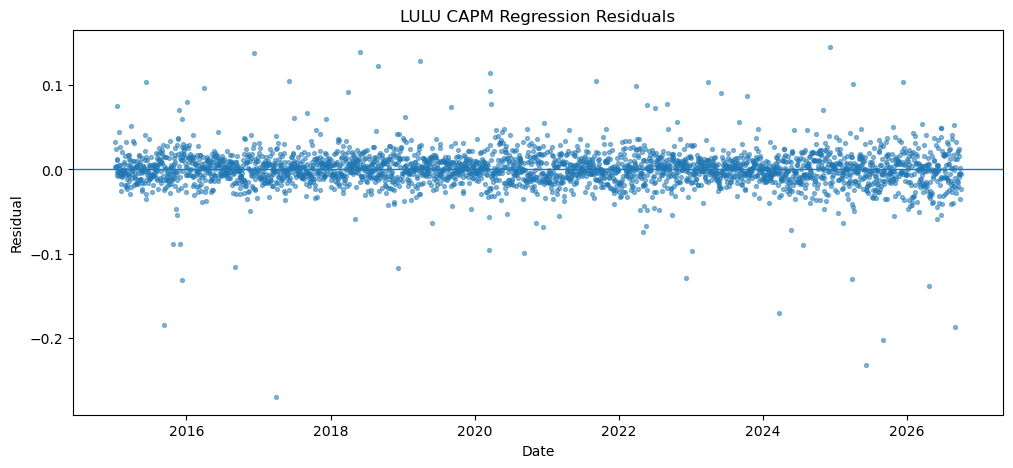

In [36]:
# Plot residuals over time
for stock in residuals.columns:
    plt.figure(figsize=(12, 5))

    plt.scatter(
        residuals.index,
        residuals[stock],
        s=8,
        alpha=0.5,
    )

    plt.axhline(
        0,
        linewidth=1,
    )

    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.title(f"{stock} CAPM Regression Residuals")

    plt.show()

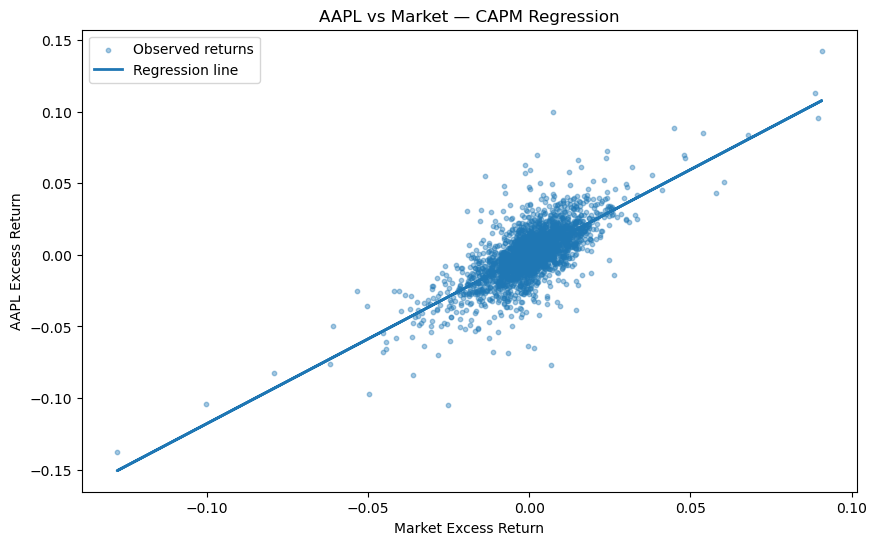

In [37]:
# Visualize the CAPM regression for AAPL
stock = "AAPL"

model = regression_results[stock]

plt.figure(figsize=(10, 6))

plt.scatter(
    market_excess_returns,
    stock_excess_returns[stock],
    s=10,
    alpha=0.4,
    label="Observed returns",
)

plt.plot(
    market_excess_returns,
    model.predict(sm.add_constant(market_excess_returns)),
    linewidth=2,
    label="Regression line",
)

plt.xlabel("Market Excess Return")
plt.ylabel(f"{stock} Excess Return")
plt.title(f"{stock} vs Market — CAPM Regression")
plt.legend()

plt.show()

In [38]:
# PHASE 4- MONTE CARLO SIMULATIONS

In [45]:
revenue_mean = log_returns_of_portfolio.mean()
revenue_std_deviation = log_returns_of_portfolio.std()
iterations = 1000

revenue = np.random.normal(loc=revenue_mean, scale=revenue_std_deviation, size=(iterations, len(log_returns_of_portfolio.columns)))
print(revenue)

[[-0.00046557 -0.0718458   0.03094768]
 [-0.01241405 -0.00051208 -0.02377878]
 [ 0.00630043 -0.0354378  -0.02899167]
 ...
 [-0.02498967  0.00611161 -0.00166567]
 [-0.01226077 -0.01746048  0.04247705]
 [ 0.01523585 -0.01448774  0.0435922 ]]


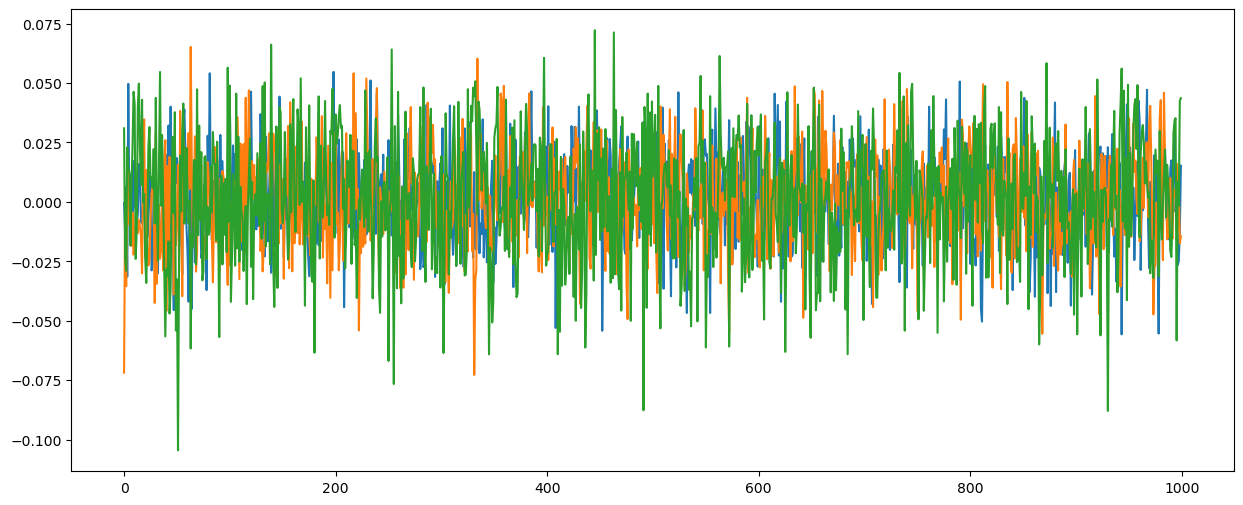

In [46]:
plt.figure(figsize=(15, 6))
plt.plot(revenue)
plt.show()

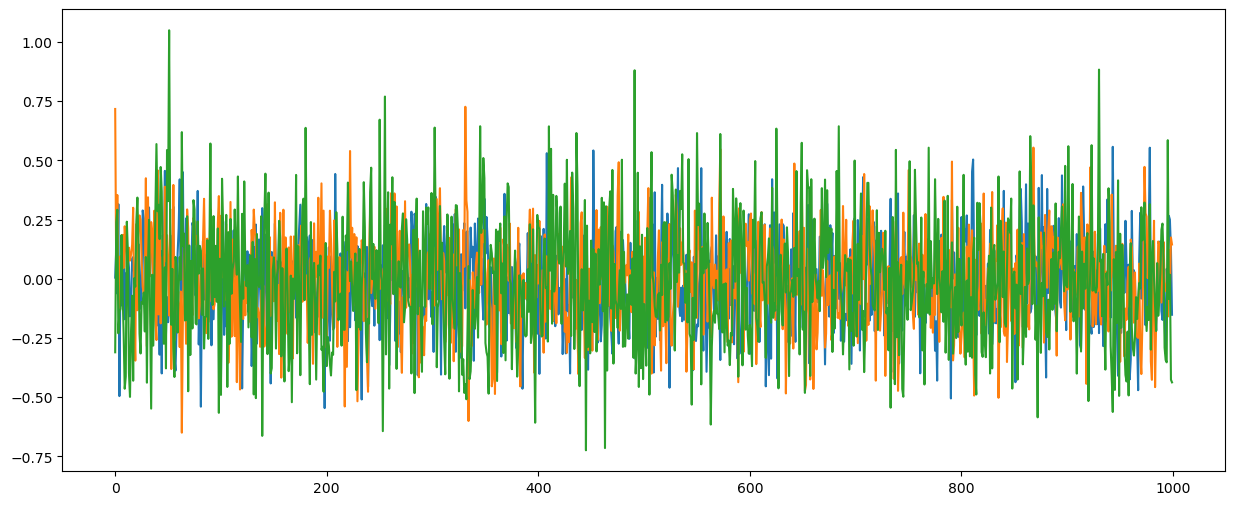

In [47]:
cogs_percentage = int(input("Enter the % of company's revenue that COGS amounts to: "))
cost_of_goods_sold = -(revenue * np.random.normal(cogs_percentage, revenue_std_deviation))

plt.figure(figsize=(15, 6))
plt.plot(cost_of_goods_sold)
plt.show()

In [48]:
gross_profit = revenue + cost_of_goods_sold
print(gross_profit)

[[ 0.00418598  0.64495215 -0.27979254]
 [ 0.11161537  0.00459688  0.2149798 ]
 [-0.0566475   0.31812138  0.2621086 ]
 ...
 [ 0.22468345 -0.05486328  0.01505901]
 [ 0.11023722  0.1567409  -0.38402758]
 [-0.13698634  0.13005487 -0.39410949]]


In [ ]:
# Price today = Price yesterday * e^( drift + random value )

# WHERE,  drift = (mu - 1/2 (sigma)^2 )
# r = ln(price today/ price yesterday)
# and e^r is a random variable;
# (one of the components of the brownian motion)


# Another formula for drift is:
#         drift = mu - 1/2 * var

# WHERE, var = variance

# daily returns = e^r
# r = drift + std * z


In [78]:
# 1. Calculate the daily mean return for each stock
daily_mu = log_returns_of_portfolio.mean()

# 2. Calculate the daily variance for each stock
daily_var = log_returns_of_portfolio.var()

# 3. Calculate daily drift using strictly daily metrics
drift = daily_mu - (0.5 * daily_var)

print("Daily Drift:\n", drift)

Daily Drift:
 AAPL    0.000725
NKE    -0.000255
LULU   -0.000154
dtype: float64


In [79]:
time_interval_of_forecast = 10000
forecast_iterations = 50
num_assets = len(drift)

# Generate random standard normal variables directly
Z = np.random.normal(0, 1, (time_interval_of_forecast, forecast_iterations, num_assets))

# Calculate daily standard deviation from the annualized version
daily_std = annualized_standard_deviation_of_stocks.values / np.sqrt(252)

# Calculate daily returns using geometric brownian motion
daily_returns = np.exp(drift.values + daily_std * Z)

print(daily_returns)

[[[1.01499578 1.01352693 0.99162951]
  [0.96085656 0.98632413 1.00774699]
  [1.00032374 0.98701469 0.98205098]
  ...
  [1.01425704 0.98010368 0.99183288]
  [1.01715977 1.00214997 0.9656931 ]
  [1.00824201 1.00451523 1.01003321]]

 [[0.99395486 0.99122265 0.96732823]
  [1.01250295 0.99581278 0.97229021]
  [1.0086653  1.00518084 0.98632299]
  ...
  [0.99323309 1.00735826 0.98257613]
  [1.00368773 1.0017973  0.95543884]
  [1.01330799 0.99348519 0.99745035]]

 [[0.99447099 0.97910749 1.01534921]
  [1.02603697 0.99686857 1.01079974]
  [0.98690643 1.00621453 1.00729524]
  ...
  [1.03988461 0.9720487  0.97257561]
  [1.02404684 1.0157589  0.97915654]
  [0.99155386 0.98516121 1.01646246]]

 ...

 [[0.98362802 1.00459957 1.01626759]
  [1.02511605 1.01485314 0.93907552]
  [0.98056619 1.0150407  1.06636616]
  ...
  [1.02542785 1.00549219 1.00323686]
  [1.00541239 0.99901426 1.01068801]
  [0.97890839 0.98186811 0.99493174]]

 [[1.01437301 0.98035799 1.00209643]
  [0.98498003 0.98539368 0.95243094]


In [80]:
# Stock price of 'i'th day = Stock price of (i-1)th day * daily return of 'i'th day
# Therefore,

# Get the most recent prices
s0 = data.iloc[-1]
print("Initial stock price:\n", s0)

# Create an empty array matching the shape of daily_returns
price_list = np.zeros_like(daily_returns)

# Set the first day's price to the current actual price
price_list[0] = s0.values

# Loop through the remaining 9,999 days to calculate future prices
for t in range(1, time_interval_of_forecast):
    price_list[t] = price_list[t - 1] * daily_returns[t]

print("Final price list:\n", price_list)

Initial stock price:
 AAPL    333.690002
NKE      33.869999
LULU     94.459999
Name: 2026-10-02 00:00:00, dtype: float64
Final price list:
 [[[3.33690002e+02 3.38699989e+01 9.44599991e+01]
  [3.33690002e+02 3.38699989e+01 9.44599991e+01]
  [3.33690002e+02 3.38699989e+01 9.44599991e+01]
  ...
  [3.33690002e+02 3.38699989e+01 9.44599991e+01]
  [3.33690002e+02 3.38699989e+01 9.44599991e+01]
  [3.33690002e+02 3.38699989e+01 9.44599991e+01]]

 [[3.31672800e+02 3.35727100e+01 9.13738236e+01]
  [3.37862113e+02 3.37281779e+01 9.18425328e+01]
  [3.36581528e+02 3.40454741e+01 9.31680685e+01]
  ...
  [3.31431951e+02 3.41192231e+01 9.28141406e+01]
  [3.34920561e+02 3.39308736e+01 9.02507521e+01]
  [3.38130747e+02 3.36493424e+01 9.42191590e+01]]

 [[3.29838978e+02 3.28712917e+01 9.27763398e+01]
  [3.46659018e+02 3.36225605e+01 9.28344081e+01]
  [3.32174476e+02 3.42570507e+01 9.38477522e+01]
  ...
  [3.44650985e+02 3.31655465e+01 9.02687690e+01]
  [3.42974340e+02 3.44655867e+01 8.83696143e+01]
  [3.